# **A. DATA PREPROCESSING: MIDDLE EASTERN AIRLINES**

# **STEP 1: INSTALLATION AND LIBRARY IMPORTS**

In [ ]:
# 1. Install required libraries
!pip install transformers tqdm datasets openpyxl

import pandas as pd
import numpy as np
import re
from tqdm.auto import tqdm
from sklearn.model_selection import train_test_split

# Configure display settings for better readability
pd.set_option('display.max_colwidth', 100)
pd.set_option('display.max_rows', 10)

# **STEP 2: DATA DISCOVERY**

In [ ]:
# 1. Load Raw Dataset for Middle Eastern Airlines
pd.set_option('display.max_colwidth', None)

# File name updated for Middle Eastern dataset
df_raw = pd.read_excel('dataset_middle eastern_airlines.xlsx')

print("--- [TABLE 1: ORIGINAL VARIABLE IDENTIFICATION - MIDDLE EASTERN AIRLINES] ---")

discovery_data = {
    'Data Source': ['Skytrax (Middle Eastern Airlines)'],
    'File Name': ['dataset_middle eastern_airlines.xlsx'],
    'Original Variables (Columns)': [ [df_raw.columns.tolist()] ],
    'Target Variables': [ ['Desc', 'Rating'] ]
}

display(pd.DataFrame(discovery_data))

--- [TABLE 1: ORIGINAL VARIABLE IDENTIFICATION - MIDDLE EASTERN AIRLINES] ---


,Data Source,File Name,Original Variables (Columns),Target Variables
0,Skytrax (Middle Eastern Airlines),dataset_middle eastern_airlines.xlsx,"[[web-scraper-order, web-scraper-start-url, Rating, Title, Desc, Aircraft, Type_travel, Seat_Type, Route, Date_Flown, Recomen, Seat, Staff Servis, FnB, Inflight Entertain, Ground, Wifi, Value, sentiment]]","[Desc, Rating]"


In [ ]:
# 2. Preview Raw Data with Center Truncation
print("\n--- [RAW DATA PREVIEW - MIDDLE EASTERN AIRLINES] ---")
print(f"Total rows    : {len(df_raw)}")
print(f"Total columns : {len(df_raw.columns)}")
print("-" * 45)

pd.set_option('display.max_colwidth', 20)
df_dots = pd.DataFrame([['...'] * len(df_raw.columns)], columns=df_raw.columns, index=['...'])
preview_raw = pd.concat([df_raw.head(5), df_dots, df_raw.tail(5)])

display(preview_raw)


--- [RAW DATA PREVIEW - MIDDLE EASTERN AIRLINES] ---
Total rows    : 3000
Total columns : 19
---------------------------------------------


,web-scraper-order,web-scraper-start-url,Rating,Title,Desc,Aircraft,Type_travel,Seat_Type,Route,Date_Flown,Recomen,Seat,Staff Servis,FnB,Inflight Entertain,Ground,Wifi,Value,sentiment
0,1760279881-1,https://www.airl...,1/10,"""still no money ...",✅ Trip Verified ...,NaN,Solo Leisure,Economy Class,Colombo to Warsa...,January 2020,no,3.0,5.0,5.0,5.0,1.0,5.0,4.0,0.0
1,1760279881-2,https://www.airl...,10/10,"""Overall, superb""",✅ Trip Verified ...,A350 900 / 1000,Couple Leisure,Business Class,Adelaide to Lond...,March 2020,yes,5.0,5.0,5.0,5.0,5.0,NaN,4.0,2.0
2,1760279881-3,https://www.airl...,10/10,"""really good ser...",Not Verified | ...,NaN,Solo Leisure,Economy Class,Doha to Cochi,March 2020,yes,4.0,5.0,5.0,4.0,4.0,4.0,4.0,2.0
3,1760279881-4,https://www.airl...,5/10,"""fly them again ...",✅ Trip Verified ...,Boeing 777-3ER,Couple Leisure,Economy Class,London to Doha,December 2019,no,4.0,5.0,1.0,3.0,3.0,NaN,2.0,1.0
4,1760279881-5,https://www.airl...,10/10,"""kindness of cab...",✅ Trip Verified ...,NaN,Business,Economy Class,Los Angeles to Doha,March 2020,yes,5.0,5.0,5.0,5.0,4.0,5.0,5.0,2.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2995,1760319064-996,https://www.airl...,3/10,"""not fly with th...",✅ Trip Verified ...,Boeing 777/787,Solo Leisure,Business Class,Sydney = to Manc...,September 2025,no,3.0,2.0,1.0,2.0,2.0,2.0,2.0,0.0
2996,1760319064-997,https://www.airl...,1/10,“nothing short o...,Not Verified | O...,NaN,Couple Leisure,First Class,Lisbon to Melbou...,September 2025,no,2.0,5.0,4.0,4.0,1.0,1.0,1.0,0.0
2997,1760319064-998,https://www.airl...,2/10,“seat was very u...,✅ Trip Verified ...,NaN,Solo Leisure,Economy Class,New York to Kolk...,September 2025,no,1.0,4.0,2.0,3.0,1.0,NaN,1.0,0.0
2998,1760319064-999,https://www.airl...,10/10,“high profession...,✅ Trip Verified ...,EY46,Family Leisure,Premium Economy,Dublin to Abu Dh...,September 2025,yes,5.0,5.0,5.0,5.0,5.0,5.0,5.0,2.0


# **STEP 3: INITIAL CLEANING & ALIGNMENT**

In [ ]:
# --- 1. DATA ALIGNMENT (VARIABLE SELECTION) ---
pd.set_option('display.max_colwidth', 100)

df_merged = pd.DataFrame()
df_merged['text_original'] = df_raw['Desc'].astype(str)
df_merged['rating_raw'] = df_raw['Rating']

print("--- [PREVIEW 1: DATA ALIGNMENT RESULTS (15 SAMPLES)] ---")
display(df_merged.head(15))

--- [PREVIEW 1: DATA ALIGNMENT RESULTS (15 SAMPLES)] ---


,text_original,rating_raw
0,✅ Trip Verified | Colombo to Warsaw via Doha in December 2019. I filed a complaint 2 months ago...,1/10
1,✅ Trip Verified | Lucky enough to fly Qatar Qsuite from London and Adelaide and back and this r...,10/10
2,"Not Verified | From Doha to Cochi. Qatar Airways Economy class is great, really good service. I...",10/10
3,✅ Trip Verified | London to Doha in economy class in December 2019. The hype of Qatar Airways m...,5/10
4,"✅ Trip Verified | Los Angeles to Doha, I was impressed with kindness of cabin crews, very polit...",10/10
...,...,...
10,✅ Trip Verified | Auckland to Helsinki via Doha. Qatar Airways did not shut down all transit tr...,10/10
11,Not Verified | Toronto to Chennai via Doha. It is troubled times with COVID-19 and India was un...,10/10
12,✅ Trip Verified | Manchester to Nairobi via Doha. This was a itinerary booked with Qatar Airway...,9/10
13,✅ Trip Verified | Prague to Kathmandu via Doha. I was generally very satisfied about flying wit...,9/10


In [ ]:
# --- 2. MISSING VALUES HANDLING ---
# Identify null or 'nan' string values
missing_count = df_merged['text_original'].replace('nan', np.nan).isnull().sum()

# Execute deletion of empty rows
df_merged.dropna(subset=['text_original'], inplace=True)

print("\n--- [REPORT 1: MISSING VALUES HANDLING] ---")
laporan_missing = pd.DataFrame({
    'Check Type': ['Empty Rows (Null/NaN)'],
    'Count': [missing_count],
    'Action': ['Removed (Dropna)']
})
display(laporan_missing)


--- [REPORT 1: MISSING VALUES HANDLING] ---


,Check Type,Count,Action
0,Empty Rows (Null/NaN),0,Removed (Dropna)


In [ ]:
# --- 3. DUPLICATE DATA HANDLING ---
# Count duplicates based on review content
duplicate_count = df_merged.duplicated(subset=['text_original']).sum()

# Execute duplicate removal (keeping the first occurrence)
df_merged.drop_duplicates(subset=['text_original'], keep='first', inplace=True)

print("\n--- [REPORT 2: DUPLICATE DATA HANDLING] ---")
laporan_duplikat = pd.DataFrame({
    'Check Type': ['Duplicate Entries'],
    'Count': [duplicate_count],
    'Action': ['Removed (Drop Duplicates)']
})
display(laporan_duplikat)


--- [REPORT 2: DUPLICATE DATA HANDLING] ---


,Check Type,Count,Action
0,Duplicate Entries,0,Removed (Drop Duplicates)


In [ ]:
# --- 4. FINAL CLEAN DATA PREVIEW ---
print("\n--- [CLEAN DATA PREVIEW: FINAL INITIAL CLEANING] ---")
print(f"Total data after initial cleaning: {len(df_merged)} rows")
print("-" * 55)

df_dots_final = pd.DataFrame([['...'] * len(df_merged.columns)],
                             columns=df_merged.columns,
                             index=['...'])

preview_final = pd.concat([df_merged.head(5), df_dots_final, df_merged.tail(5)])
display(preview_final)


--- [CLEAN DATA PREVIEW: FINAL INITIAL CLEANING] ---
Total data after initial cleaning: 3000 rows
-------------------------------------------------------


,text_original,rating_raw
0,✅ Trip Verified | Colombo to Warsaw via Doha in December 2019. I filed a complaint 2 months ago...,1/10
1,✅ Trip Verified | Lucky enough to fly Qatar Qsuite from London and Adelaide and back and this r...,10/10
2,"Not Verified | From Doha to Cochi. Qatar Airways Economy class is great, really good service. I...",10/10
3,✅ Trip Verified | London to Doha in economy class in December 2019. The hype of Qatar Airways m...,5/10
4,"✅ Trip Verified | Los Angeles to Doha, I was impressed with kindness of cabin crews, very polit...",10/10
...,...,...
2995,✅ Trip Verified | This airline sells business class tickets without lounge access. So really thi...,3/10
2996,Not Verified | Our experience with Etihad was nothing short of terrible. Our flight from Lisbon ...,1/10
2997,✅ Trip Verified | No wheelchair was available at AUH despite pre-booking. As I have very low c...,2/10
2998,✅ Trip Verified | I want to take a moment to express my appreciation for the exceptional service...,10/10


# **STEP 4: TEXT PREPROCESSING**

In [ ]:
# --- 1. CLEANING (Remove Skytrax Tags, URLs, Symbols, and Numbers) ---
def cleaning(text):
    text = re.sub(r'✅ Trip Verified |\|', '', text) # Remove verified tag
    text = re.sub(r'Not Verified |\|', '', text)    # Remove not verified tag
    text = re.sub(r'http\S+|www\S+|https\S+', ' ', text) # Remove URLs
    text = re.sub(r'[^a-zA-Z\s]', ' ', text)           # Remove symbols & numbers
    return re.sub(r'\s+', ' ', text).strip() # Remove extra whitespaces

# Execute Cleaning
df_merged['Result_Cleaning'] = df_merged['text_original'].apply(cleaning)

print("--- [PREVIEW 1: CLEANING STAGE (NON-TEXT REMOVAL)] ---")
display(df_merged[['text_original', 'Result_Cleaning']].head(10))

--- [PREVIEW 1: CLEANING STAGE (NON-TEXT REMOVAL)] ---


,text_original,Result_Cleaning
0,✅ Trip Verified | Colombo to Warsaw via Doha in December 2019. I filed a complaint 2 months ago...,Colombo to Warsaw via Doha in December I filed a complaint months ago and still no money back Th...
1,✅ Trip Verified | Lucky enough to fly Qatar Qsuite from London and Adelaide and back and this r...,Lucky enough to fly Qatar Qsuite from London and Adelaide and back and this review encompasses b...
2,"Not Verified | From Doha to Cochi. Qatar Airways Economy class is great, really good service. I...",From Doha to Cochi Qatar Airways Economy class is great really good service I am very impressed ...
3,✅ Trip Verified | London to Doha in economy class in December 2019. The hype of Qatar Airways m...,London to Doha in economy class in December The hype of Qatar Airways must be to do with their b...
4,"✅ Trip Verified | Los Angeles to Doha, I was impressed with kindness of cabin crews, very polit...",Los Angeles to Doha I was impressed with kindness of cabin crews very polite and helpful Ashmeyt...
5,"✅ Trip Verified | Johannesburg to Danang via Doha 13 March 2020. And, back on the same route du...",Johannesburg to Danang via Doha March And back on the same route due to denied access to Vietnam...
6,"✅ Trip Verified | Qatar Airways business class is great, really good service. We had a 13 hour ...",Qatar Airways business class is great really good service We had a hour delay coming back from P...
7,✅ Trip Verified | Amman to Sydney via Doha. We are very impressed by cabin crew Inoula and Cata...,Amman to Sydney via Doha We are very impressed by cabin crew Inoula and Catalina who served the ...
8,"✅ Trip Verified | Birmingham to Goa via Doha. he food served to me was not great, on the return...",Birmingham to Goa via Doha he food served to me was not great on the return journey it was worse...
9,✅ Trip Verified | I had the pleasure of experiencing the A380 from London to Sydney via Doha. T...,I had the pleasure of experiencing the A from London to Sydney via Doha Their A business seats a...


In [ ]:
# --- 2. CASE FOLDING (Lowercase Conversion) ---
df_merged['Result_Case_Folding'] = df_merged['Result_Cleaning'].str.lower()

print("\n--- [PREVIEW 2: CASE FOLDING STAGE (LOWERCASE)] ---")
display(df_merged[['Result_Cleaning', 'Result_Case_Folding']].head(10))


--- [PREVIEW 2: CASE FOLDING STAGE (LOWERCASE)] ---


,Result_Cleaning,Result_Case_Folding
0,Colombo to Warsaw via Doha in December I filed a complaint months ago and still no money back Th...,colombo to warsaw via doha in december i filed a complaint months ago and still no money back th...
1,Lucky enough to fly Qatar Qsuite from London and Adelaide and back and this review encompasses b...,lucky enough to fly qatar qsuite from london and adelaide and back and this review encompasses b...
2,From Doha to Cochi Qatar Airways Economy class is great really good service I am very impressed ...,from doha to cochi qatar airways economy class is great really good service i am very impressed ...
3,London to Doha in economy class in December The hype of Qatar Airways must be to do with their b...,london to doha in economy class in december the hype of qatar airways must be to do with their b...
4,Los Angeles to Doha I was impressed with kindness of cabin crews very polite and helpful Ashmeyt...,los angeles to doha i was impressed with kindness of cabin crews very polite and helpful ashmeyt...
5,Johannesburg to Danang via Doha March And back on the same route due to denied access to Vietnam...,johannesburg to danang via doha march and back on the same route due to denied access to vietnam...
6,Qatar Airways business class is great really good service We had a hour delay coming back from P...,qatar airways business class is great really good service we had a hour delay coming back from p...
7,Amman to Sydney via Doha We are very impressed by cabin crew Inoula and Catalina who served the ...,amman to sydney via doha we are very impressed by cabin crew inoula and catalina who served the ...
8,Birmingham to Goa via Doha he food served to me was not great on the return journey it was worse...,birmingham to goa via doha he food served to me was not great on the return journey it was worse...
9,I had the pleasure of experiencing the A from London to Sydney via Doha Their A business seats a...,i had the pleasure of experiencing the a from london to sydney via doha their a business seats a...


In [ ]:
# --- 3. NORMALIZATION (Middle Eastern Hubs & English Contractions) ---
norm_dict = {
    # Aviation Specific
    'flt': 'flight', 'flts': 'flights', 'apt': 'airport', 'ife': 'entertainment',
    'cabin crew': 'staff', 'flight crew': 'staff', 'ground crew': 'staff', 'crews': 'crew',
    'inflight': 'in flight', 'onboard': 'on board', 'pax': 'passenger', 'layover': 'stopover',
    'ptv': 'personal television', 'f b': 'food and beverage', 'fnb': 'food and beverage',

    # Middle Eastern Hubs & Carriers
    'dxb': 'dubai', 'doh': 'doha', 'auh': 'abu dhabi', 'ist': 'istanbul',
    'ruh': 'riyadh', 'jed': 'jeddah', 'mct': 'muscat', 'kwi': 'kuwait',
    'qatar': 'qatar airways', 'emirates': 'emirates', 'etihad': 'etihad airways',
    'qr': 'qatar airways', 'ek': 'emirates', 'ey': 'etihad airways',
    'tk': 'turkish airlines', 'sv': 'saudia', 'wy': 'oman air',

    # English Contractions (Critical for Transformer Negation Understanding)
    "don t": "do not", "dont": "do not", "didn t": "did not", "didnt": "did not",
    "can t": "cannot", "cant": "cannot", "wasn t": "was not", "wasnt": "was not",
    "it s": "it is", "its": "it is", "i m": "i am", "im": "i am", "i ve": "i have",
    "ive": "i have", "won t": "will not", "wont": "will not", "couldn t": "could not",
    "shouldn t": "should not", "hasn t": "has not", "weren t": "were not", "i d": "i would",

    # Informal & Units
    'u': 'you', 'r': 'are', 'b': 'be', 'n': 'and', 'w': 'with', 'v': 'very',
    'ok': 'good', 'thx': 'thanks', 'tks': 'thanks', 'pls': 'please',
    'hrs': 'hours', 'mins': 'minutes', 'approx': 'approximately', 'yr': 'year',

    # Sentiment-heavy Adjectives
    'flyin': 'flying', 'lookin': 'looking', 'travelled': 'traveled', 'fav': 'favorite',
    'excellent': 'good', 'efficient': 'good', 'terrible': 'bad', 'awful': 'bad',
    'horrible': 'bad', 'expensive': 'high price', 'comfy': 'comfortable'
}

def normalization(text):
    # Regex to replace only whole words
    pattern = re.compile(r'\b(' + '|'.join(re.escape(key) for key in norm_dict.keys()) + r')\b')
    return pattern.sub(lambda x: norm_dict[x.group()], text)

# Execute Normalization
df_merged['Result_Normalization'] = df_merged['Result_Case_Folding'].apply(normalization)

print("\n--- [PREVIEW 3: NORMALIZATION STAGE (EXTENSIVE DICTIONARY)] ---")
display(df_merged[['Result_Case_Folding', 'Result_Normalization']].head(10))


--- [PREVIEW 3: NORMALIZATION STAGE (EXTENSIVE DICTIONARY)] ---


,Result_Case_Folding,Result_Normalization
0,colombo to warsaw via doha in december i filed a complaint months ago and still no money back th...,colombo to warsaw via doha in december i filed a complaint months ago and still no money back th...
1,lucky enough to fly qatar qsuite from london and adelaide and back and this review encompasses b...,lucky enough to fly qatar airways qsuite from london and adelaide and back and this review encom...
2,from doha to cochi qatar airways economy class is great really good service i am very impressed ...,from doha to cochi qatar airways airways economy class is great really good service i am very im...
3,london to doha in economy class in december the hype of qatar airways must be to do with their b...,london to doha in economy class in december the hype of qatar airways airways must be to do with...
4,los angeles to doha i was impressed with kindness of cabin crews very polite and helpful ashmeyt...,los angeles to doha i was impressed with kindness of cabin crew very polite and helpful ashmeyta...
5,johannesburg to danang via doha march and back on the same route due to denied access to vietnam...,johannesburg to danang via doha march and back on the same route due to denied access to vietnam...
6,qatar airways business class is great really good service we had a hour delay coming back from p...,qatar airways airways business class is great really good service we had a hour delay coming bac...
7,amman to sydney via doha we are very impressed by cabin crew inoula and catalina who served the ...,amman to sydney via doha we are very impressed by staff inoula and catalina who served the upper...
8,birmingham to goa via doha he food served to me was not great on the return journey it was worse...,birmingham to goa via doha he food served to me was not great on the return journey it was worse...
9,i had the pleasure of experiencing the a from london to sydney via doha their a business seats a...,i had the pleasure of experiencing the a from london to sydney via doha their a business seats a...


In [ ]:
# --- 4. TOKENIZATION (Splitting Sentences into Words) ---
df_merged['Result_Tokenizing'] = df_merged['Result_Normalization'].apply(lambda x: x.split())

print("\n--- [PREVIEW 4: TOKENIZATION STAGE (SPLIT WORDS)] ---")
display(df_merged[['Result_Normalization', 'Result_Tokenizing']].head(10))


--- [PREVIEW 4: TOKENIZATION STAGE (SPLIT WORDS)] ---


,Result_Normalization,Result_Tokenizing
0,colombo to warsaw via doha in december i filed a complaint months ago and still no money back th...,"[colombo, to, warsaw, via, doha, in, december, i, filed, a, complaint, months, ago, and, still, ..."
1,lucky enough to fly qatar airways qsuite from london and adelaide and back and this review encom...,"[lucky, enough, to, fly, qatar, airways, qsuite, from, london, and, adelaide, and, back, and, th..."
2,from doha to cochi qatar airways airways economy class is great really good service i am very im...,"[from, doha, to, cochi, qatar, airways, airways, economy, class, is, great, really, good, servic..."
3,london to doha in economy class in december the hype of qatar airways airways must be to do with...,"[london, to, doha, in, economy, class, in, december, the, hype, of, qatar, airways, airways, mus..."
4,los angeles to doha i was impressed with kindness of cabin crew very polite and helpful ashmeyta...,"[los, angeles, to, doha, i, was, impressed, with, kindness, of, cabin, crew, very, polite, and, ..."
5,johannesburg to danang via doha march and back on the same route due to denied access to vietnam...,"[johannesburg, to, danang, via, doha, march, and, back, on, the, same, route, due, to, denied, a..."
6,qatar airways airways business class is great really good service we had a hour delay coming bac...,"[qatar, airways, airways, business, class, is, great, really, good, service, we, had, a, hour, d..."
7,amman to sydney via doha we are very impressed by staff inoula and catalina who served the upper...,"[amman, to, sydney, via, doha, we, are, very, impressed, by, staff, inoula, and, catalina, who, ..."
8,birmingham to goa via doha he food served to me was not great on the return journey it was worse...,"[birmingham, to, goa, via, doha, he, food, served, to, me, was, not, great, on, the, return, jou..."
9,i had the pleasure of experiencing the a from london to sydney via doha their a business seats a...,"[i, had, the, pleasure, of, experiencing, the, a, from, london, to, sydney, via, doha, their, a,..."


In [ ]:
# --- FINAL PREPROCESSING SUMMARY ---
print("\n--- [SUMMARY TABLE: TEXT TRANSFORMATION FROM START TO FINISH] ---")
display(df_merged[[
    'text_original',
    'Result_Cleaning',
    'Result_Case_Folding',
    'Result_Normalization',
    'Result_Tokenizing'
]].head(10))


--- [SUMMARY TABLE: TEXT TRANSFORMATION FROM START TO FINISH] ---


,text_original,Result_Cleaning,Result_Case_Folding,Result_Normalization,Result_Tokenizing
0,✅ Trip Verified | Colombo to Warsaw via Doha in December 2019. I filed a complaint 2 months ago...,Colombo to Warsaw via Doha in December I filed a complaint months ago and still no money back Th...,colombo to warsaw via doha in december i filed a complaint months ago and still no money back th...,colombo to warsaw via doha in december i filed a complaint months ago and still no money back th...,"[colombo, to, warsaw, via, doha, in, december, i, filed, a, complaint, months, ago, and, still, ..."
1,✅ Trip Verified | Lucky enough to fly Qatar Qsuite from London and Adelaide and back and this r...,Lucky enough to fly Qatar Qsuite from London and Adelaide and back and this review encompasses b...,lucky enough to fly qatar qsuite from london and adelaide and back and this review encompasses b...,lucky enough to fly qatar airways qsuite from london and adelaide and back and this review encom...,"[lucky, enough, to, fly, qatar, airways, qsuite, from, london, and, adelaide, and, back, and, th..."
2,"Not Verified | From Doha to Cochi. Qatar Airways Economy class is great, really good service. I...",From Doha to Cochi Qatar Airways Economy class is great really good service I am very impressed ...,from doha to cochi qatar airways economy class is great really good service i am very impressed ...,from doha to cochi qatar airways airways economy class is great really good service i am very im...,"[from, doha, to, cochi, qatar, airways, airways, economy, class, is, great, really, good, servic..."
3,✅ Trip Verified | London to Doha in economy class in December 2019. The hype of Qatar Airways m...,London to Doha in economy class in December The hype of Qatar Airways must be to do with their b...,london to doha in economy class in december the hype of qatar airways must be to do with their b...,london to doha in economy class in december the hype of qatar airways airways must be to do with...,"[london, to, doha, in, economy, class, in, december, the, hype, of, qatar, airways, airways, mus..."
4,"✅ Trip Verified | Los Angeles to Doha, I was impressed with kindness of cabin crews, very polit...",Los Angeles to Doha I was impressed with kindness of cabin crews very polite and helpful Ashmeyt...,los angeles to doha i was impressed with kindness of cabin crews very polite and helpful ashmeyt...,los angeles to doha i was impressed with kindness of cabin crew very polite and helpful ashmeyta...,"[los, angeles, to, doha, i, was, impressed, with, kindness, of, cabin, crew, very, polite, and, ..."
5,"✅ Trip Verified | Johannesburg to Danang via Doha 13 March 2020. And, back on the same route du...",Johannesburg to Danang via Doha March And back on the same route due to denied access to Vietnam...,johannesburg to danang via doha march and back on the same route due to denied access to vietnam...,johannesburg to danang via doha march and back on the same route due to denied access to vietnam...,"[johannesburg, to, danang, via, doha, march, and, back, on, the, same, route, due, to, denied, a..."
6,"✅ Trip Verified | Qatar Airways business class is great, really good service. We had a 13 hour ...",Qatar Airways business class is great really good service We had a hour delay coming back from P...,qatar airways business class is great really good service we had a hour delay coming back from p...,qatar airways airways business class is great really good service we had a hour delay coming bac...,"[qatar, airways, airways, business, class, is, great, really, good, service, we, had, a, hour, d..."
7,✅ Trip Verified | Amman to Sydney via Doha. We are very impressed by cabin crew Inoula and Cata...,Amman to Sydney via Doha We are very impressed by cabin crew Inoula and Catalina who served the ...,amman to sydney via doha we are very impressed by cabin crew inoula and catalina who served the ...,amman to sydney via doha we are very impressed by staff inoula and catalina who 

# **STEP 5: DATA LABELING (RATING-BASED)**

In [ ]:
def rating_labelling(val):
    try:
        # Extract pure numeric score from 'X/10' format
        if isinstance(val, str) and '/' in val:
            score = int(val.split('/')[0])
        else:
            score = int(val)

        # Determine Ordinal Labels (0: Negative, 1: Neutral, 2: Positive)
        if score <= 4:
            return 'negative', 0
        elif score <= 6:
            return 'neutral', 1
        else:
            return 'positive', 2
    except:
        # Fallback to neutral in case of missing or corrupted data
        return 'neutral', 1

# Execute Labeling Process
results = df_merged['rating_raw'].apply(rating_labelling)
df_merged[['sentiment_name', 'label']] = pd.DataFrame(results.tolist(), index=df_merged.index)

print("--- [LABELING VERIFICATION: 1-10 RATING REPRESENTATION] ---")

pd.set_option('display.max_rows', 20)
pd.set_option('display.max_colwidth', 60)

# Retrieve unique examples for each rating score (1-10) for verification
verification_samples = df_merged.drop_duplicates(subset=['rating_raw']).sort_values(by='label')

display(verification_samples[['Result_Normalization', 'rating_raw', 'sentiment_name', 'label']])

# Display distribution statistics
print("\n--- [LABELING STATISTICS SUMMARY] ---")
print(df_merged['sentiment_name'].value_counts())

--- [LABELING VERIFICATION: 1-10 RATING REPRESENTATION] ---


,Result_Normalization,rating_raw,sentiment_name,label
0,colombo to warsaw via doha in december i filed a complai...,1/10,negative,0
5,johannesburg to danang via doha march and back on the sa...,2/10,negative,0
8,birmingham to goa via doha he food served to me was not ...,4/10,negative,0
164,i had a flight from tehran to seattle via doha the fligh...,3/10,negative,0
206,service as always on point lots of children in business ...,6/10,neutral,1
3,london to doha in economy class in december the hype of ...,5/10,neutral,1
1,lucky enough to fly qatar airways qsuite from london and...,10/10,positive,2
12,manchester to nairobi via doha this was a itinerary book...,9/10,positive,2
22,amritsar to vancouver via doha best airline service all ...,8/10,positive,2
17,helsinki to delhi via delhi good service from helsinki t...,7/10,positive,2



--- [LABELING STATISTICS SUMMARY] ---
sentiment_name
negative    1655
positive    1032
neutral      313
Name: count, dtype: int64


# **STEP 6: DATA EXPORT & VISUALIZATION**

In [ ]:
# --- 1. SAVE TO EXCEL ---
nama_file = "dataset_middle_eastern_preprocessing.xlsx"
df_merged.to_excel(nama_file, index=False)

print(f"\n[INFO] File successfully saved as: {nama_file}")


[INFO] File successfully saved as: dataset_middle_eastern_preprocessing.xlsx


/tmp/ipykernel_2048/1188285387.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=sentiment_counts.index, y=sentiment_counts.values, palette=['#e74c3c', '#2ecc71', '#f1c40f'])


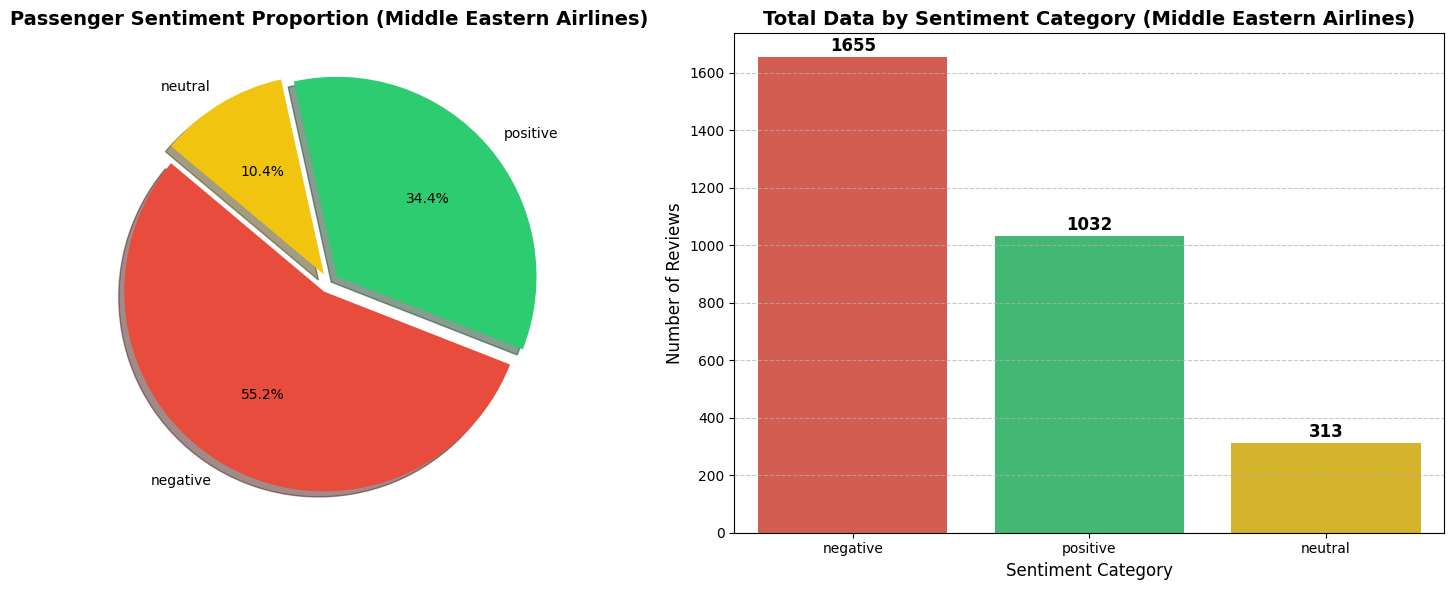

In [ ]:
# --- 2. SENTIMENT DISTRIBUTION VISUALIZATION ---
import matplotlib.pyplot as plt
import seaborn as sns

# Prepare data for plotting
sentiment_counts = df_merged['sentiment_name'].value_counts()
# Define aesthetic properties
explode = (0.05, 0.05, 0.05)

# Initialize visualization canvas
plt.figure(figsize=(15, 6))

# --- SUBPLOT 1: PIE CHART (PROPORTION) ---
plt.subplot(1, 2, 1)
plt.pie(sentiment_counts, labels=sentiment_counts.index, autopct='%1.1f%%',
        startangle=140, colors=['#e74c3c', '#2ecc71', '#f1c40f'], explode=explode, shadow=True)
plt.title('Passenger Sentiment Proportion (Middle Eastern Airlines)', fontsize=14, fontweight='bold')

# --- SUBPLOT 2: BAR CHART (TOTAL COUNTS) ---
plt.subplot(1, 2, 2)
sns.barplot(x=sentiment_counts.index, y=sentiment_counts.values, palette=['#e74c3c', '#2ecc71', '#f1c40f'])

# Add data labels on top of each bar for better readability
for i, v in enumerate(sentiment_counts.values):
    plt.text(i, v + 20, str(v), ha='center', fontweight='bold', fontsize=12)

# Mengubah 'per' menjadi 'by' agar lebih 'English'
plt.title('Total Data by Sentiment Category (Middle Eastern Airlines)', fontsize=14, fontweight='bold')
plt.xlabel('Sentiment Category', fontsize=12)
plt.ylabel('Number of Reviews', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

# **TAHAP 6: DATA SPLITTING**

In [ ]:
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# 1. Splitting the dataset
df_train, df_test = train_test_split(
    df_merged,
    test_size=0.2,
    random_state=42,
    stratify=df_merged['label']
)

print(f"--- [DATASET SPLIT INFORMATION] ---")
print(f"Total Training Samples (80%): {len(df_train)}")
print(f"Total Testing Samples (20%) : {len(df_test)}")

--- [DATASET SPLIT INFORMATION] ---
Total Training Samples (80%): 2400
Total Testing Samples (20%) : 600


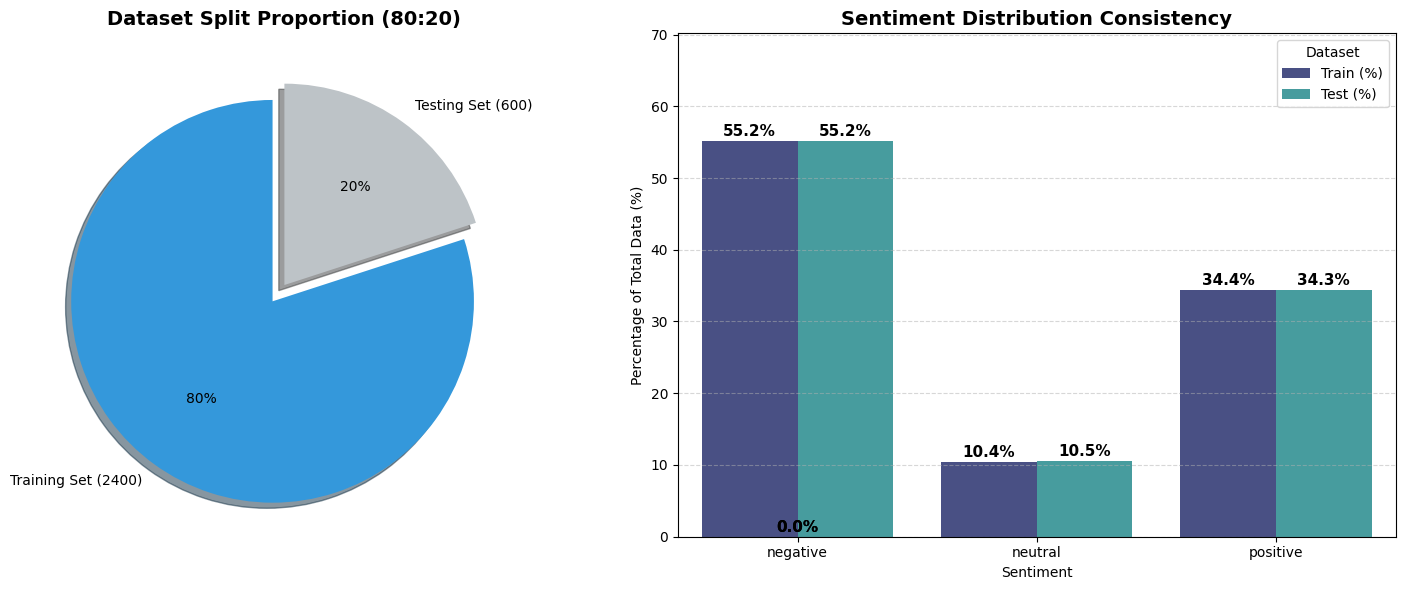

In [ ]:
# 2. Dataset Split & Stratification Visualization
split_counts = [len(df_train), len(df_test)]
split_labels = [f'Training Set ({len(df_train)})', f'Testing Set ({len(df_test)})']

train_dist = df_train['sentiment_name'].value_counts(normalize=True).sort_index() * 100
test_dist = df_test['sentiment_name'].value_counts(normalize=True).sort_index() * 100

df_dist = pd.DataFrame({
    'Sentiment': train_dist.index,
    'Train (%)': train_dist.values,
    'Test (%)': test_dist.values
}).melt(id_vars='Sentiment', var_name='Dataset', value_name='Percentage')

plt.figure(figsize=(15, 6))

# Subplot 1: Pie Chart (Proportion)
plt.subplot(1, 2, 1)
plt.pie(split_counts, labels=split_labels, autopct='%1.0f%%',
        startangle=90, colors=['#3498db', '#bdc3c7'], explode=(0.1, 0), shadow=True)
plt.title('Dataset Split Proportion (80:20)', fontsize=14, fontweight='bold')

# Subplot 2: Grouped Bar Chart (Stratification Check)
plt.subplot(1, 2, 2)
sns.barplot(data=df_dist, x='Sentiment', y='Percentage', hue='Dataset', palette='mako')

for p in plt.gca().patches:
    plt.gca().annotate(f'{p.get_height():.1f}%',
                       (p.get_x() + p.get_width() / 2., p.get_height()),
                       ha='center', va='center', fontsize=11, color='black',
                       xytext=(0, 7), textcoords='offset points', fontweight='bold')

plt.title('Sentiment Distribution Consistency', fontsize=14, fontweight='bold')
plt.ylabel('Percentage of Total Data (%)')
plt.ylim(0, max(df_dist['Percentage']) + 15)
plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

# **B. TRANSFORMER TOKENIZATION LAYER**

In [ ]:
from transformers import AutoTokenizer
from tqdm.auto import tqdm

# Configure Pandas for full text visibility
pd.set_option('display.max_colwidth', None)
pd.set_option('display.expand_frame_repr', False)

architectures = {
    "BERT": "bert-base-uncased",
    "RoBERTa": "roberta-base",
    "DeBERTa": "microsoft/deberta-base"
}

# Select sample review from Middle Eastern training data
sample_review = df_train['Result_Normalization'].iloc[0]

print(f"--- [STEP B: CROSS-ARCHITECTURE TOKENIZATION VIEW] ---")
print(f"Original Review: {sample_review}\n")

comparison_list = []

for name, path in tqdm(architectures.items(), desc="Processing"):
    tokenizer = AutoTokenizer.from_pretrained(path)
    input_ids = tokenizer.encode(sample_review, add_special_tokens=True)
    full_tokens = tokenizer.convert_ids_to_tokens(input_ids)

    comparison_list.append({
        'Architecture': name,
        'Full Token Sequence': " | ".join(full_tokens),
        'Total Tokens': len(full_tokens)
    })

df_compare = pd.DataFrame(comparison_list)
display(df_compare)

--- [STEP B: CROSS-ARCHITECTURE TOKENIZATION VIEW] ---
Original Review: very small portion of food served during the flight long queue at check in counter i waited for hours despite of not over crowded partnership with several airlines and credit cards are discontinued poor customer service to solve the missing mileage due to the termination of partnership airlines



Processing:   0%|          | 0/3 [00:00<?, ?it/s]

,Architecture,Full Token Sequence,Total Tokens
0,BERT,[CLS] | very | small | portion | of | food | served | during | the | flight | long | queue | at | check | in | counter | i | waited | for | hours | despite | of | not | over | crowded | partnership | with | several | airlines | and | credit | cards | are | discontinued | poor | customer | service | to | solve | the | missing | mile | ##age | due | to | the | termination | of | partnership | airlines | [SEP],51
1,RoBERTa,<s> | very | Ġsmall | Ġportion | Ġof | Ġfood | Ġserved | Ġduring | Ġthe | Ġflight | Ġlong | Ġqueue | Ġat | Ġcheck | Ġin | Ġcounter | Ġi | Ġwaited | Ġfor | Ġhours | Ġdespite | Ġof | Ġnot | Ġover | Ġcrowded | Ġpartnership | Ġwith | Ġseveral | Ġairlines | Ġand | Ġcredit | Ġcards | Ġare | Ġdiscontinued | Ġpoor | Ġcustomer | Ġservice | Ġto | Ġsolve | Ġthe | Ġmissing | Ġmileage | Ġdue | Ġto | Ġthe | Ġtermination | Ġof | Ġpartnership | Ġairlines | </s>,50
2,DeBERTa,[CLS] | very | Ġsmall | Ġportion | Ġof | Ġfood | Ġserved | Ġduring | Ġthe | Ġflight | Ġlong | Ġqueue | Ġat | Ġcheck | Ġin | Ġcounter | Ġi | Ġwaited | Ġfor | Ġhours | Ġdespite | Ġof | Ġnot | Ġover | Ġcrowded | Ġpartnership | Ġwith | Ġseveral | Ġairlines | Ġand | Ġcredit | Ġcards | Ġare | Ġdiscontinued | Ġpoor | Ġcustomer | Ġservice | Ġto | Ġsolve | Ġthe | Ġmissing | Ġmileage | Ġdue | Ġto | Ġthe | Ġtermination | Ġof | Ġpartnership | Ġairlines | [SEP],50


# **C. FINE-TUNE TASK (BERT, ROBERTA, DEBERTA)**

# **STEP 1: GLOBAL CONFIGURATION & ASPECT DETECTION**

In [ ]:
import torch
import torch.nn as nn
import random
import numpy as np
import os
import pandas as pd
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer
)
from sklearn.metrics import accuracy_score, f1_score
from torch.utils.data import Dataset

# Global Seed Configuration
def set_seed(seed_value=42):
    random.seed(seed_value)
    np.random.seed(seed_value)
    torch.manual_seed(seed_value)
    torch.cuda.manual_seed_all(seed_value)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    os.environ['PYTHONHASHSEED'] = str(seed_value)
    print(f"System locked with Seed: {seed_value}")

set_seed(42)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Dataset Class Definition
class AirlineReviewDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_len=128):
        self.texts = texts.tolist()
        self.labels = labels.tolist()
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        text = str(self.texts[idx])
        inputs = self.tokenizer(
            text,
            truncation=True,
            padding='max_length',
            max_length=self.max_len,
            return_tensors='pt'
        )
        return {
            'input_ids': inputs['input_ids'].flatten(),
            'attention_mask': inputs['attention_mask'].flatten(),
            'labels': torch.tensor(self.labels[idx], dtype=torch.long)
        }

# Evaluation Metrics Function
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)
    return {
        'accuracy': accuracy_score(labels, predictions),
        'f1_macro': f1_score(labels, predictions, average='macro')
    }

# Aspect Detection Function (Middle Eastern Context with Aspect_ prefix)
def add_aspect_detection_me(df):
    rules = {
        'Aspect_Staff_Service': [
            'staff', 'crew', 'service', 'attendant',
            'polite', 'friendly', 'helpful', 'hospitality'
        ],
        'Aspect_FnB': [
            'food', 'meal', 'drink', 'beverage', 'catering',
            'delicious', 'breakfast', 'lunch', 'dinner',
            'snack', 'coffee', 'dates'
        ],
        'Aspect_Inflight_Entertain': [
            'ife', 'entertainment', 'movie', 'screen',
            'video', 'music', 'game', 'tv'
        ],
        'Aspect_Ground': [
            'ground', 'check in', 'boarding', 'lounge',
            'airport', 'counter', 'queue', 'gate',
            'transit', 'transfer'
        ],
        'Aspect_Wifi': [
            'wifi', 'internet', 'connectivity',
            'connection', 'web'
        ]
    }
    for aspect, keywords in rules.items():
        df[aspect] = df['Result_Normalization'].apply(
            lambda x: 1 if any(word in str(x).lower() for word in keywords) else 0
        )
    return df

# Execute Aspect Detection
df_train = add_aspect_detection_me(df_train.copy())
df_test = add_aspect_detection_me(df_test.copy())

print("Step 1 Complete: Aspect Detection for Middle Eastern dataset configured.")

System locked with Seed: 42
Step 1 Complete: Aspect Detection for Middle Eastern dataset configured.


# **STEP 2: BERT MODEL FINE-TUNING**

In [ ]:
import pandas as pd
pd.set_option('display.max_colwidth', 50)

In [ ]:
print(f"\n{'='*60}\nSTEP 1: BERT MODEL - SENTIMENT & ASPECT DETECTION\n{'='*60}")

# 1. Load Model & Tokenizer
path_bert = "bert-base-uncased"
tokenizer_bert = AutoTokenizer.from_pretrained(path_bert)
model_bert = AutoModelForSequenceClassification.from_pretrained(
    path_bert,
    num_labels=3
).to(device)

# 2. Training Configuration
args_bert = TrainingArguments(
    output_dir='./res_bert_me',
    num_train_epochs=3,
    per_device_train_batch_size=16,
    learning_rate=2e-5,
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    seed=42,
    data_seed=42,
    report_to="none"
)

# 3. Training Execution
trainer_bert = Trainer(
    model=model_bert,
    args=args_bert,
    train_dataset=AirlineReviewDataset(
        df_train['Result_Normalization'],
        df_train['label'],
        tokenizer_bert
    ),
    eval_dataset=AirlineReviewDataset(
        df_test['Result_Normalization'],
        df_test['label'],
        tokenizer_bert
    ),
    compute_metrics=compute_metrics
)

print("Training BERT-Base-Uncased...")
trainer_bert.train()

# 4. Generate Predictions
output_bert = trainer_bert.predict(
    AirlineReviewDataset(
        df_test['Result_Normalization'],
        df_test['label'],
        tokenizer_bert
    )
)
preds_bert = np.argmax(output_bert.predictions, axis=-1)

df_res_bert = df_test.copy()
df_res_bert['Sentiment_BERT'] = pd.Series(
    preds_bert,
    index=df_test.index
).map({0: 'negative', 1: 'neutral', 2: 'positive'})

# --- [VERIFICATION BLOCK] ---
print("\n[VERIFICATION] Prediction distribution across all classes:")
print(df_res_bert['Sentiment_BERT'].value_counts())

# 5. Output Verification
print("\n" + "="*60)
print("--- [FINAL OUTPUT: BERT SENTIMENT & ASPECT DETECTION] ---")
print("="*60)

display(df_res_bert[[
    'Result_Normalization',
    'sentiment_name',
    'Sentiment_BERT',
    'Aspect_Staff_Service',
    'Aspect_FnB',
    'Aspect_Inflight_Entertain',
    'Aspect_Ground',
    'Aspect_Wifi'
]].head(10))


STEP 1: BERT MODEL - SENTIMENT & ASPECT DETECTION


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Training BERT-Base-Uncased...


Epoch,Training Loss,Validation Loss,Accuracy,F1 Macro
1,No log,0.422947,0.845000,0.597076
2,No log,0.422609,0.850000,0.674297
3,No log,0.424769,0.850000,0.694730


...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.attention.output.La


[VERIFICATION] Prediction distribution across all classes:
Sentiment_BERT
negative    383
positive    187
neutral      30
Name: count, dtype: int64

--- [FINAL OUTPUT: BERT SENTIMENT & ASPECT DETECTION] ---


,Result_Normalization,sentiment_name,Sentiment_BERT,Aspect_Staff_Service,Aspect_FnB,Aspect_Inflight_Entertain,Aspect_Ground,Aspect_Wifi
528,booked single business class flight from ho ch...,positive,positive,1,1,0,1,0
539,i have been taking qatar airways airways for y...,positive,positive,1,0,0,0,0
1659,superb service from emirates i had to cancel m...,positive,negative,1,0,0,0,0
1588,first of all on the return flight the staff de...,negative,negative,1,1,1,1,1
2097,mumbai to johannesburg via abu dhabi with my p...,negative,negative,1,0,0,1,0
973,flying business class with qatar airways airwa...,positive,positive,1,0,0,0,0
2393,abu dhabi to london i have flown with them bef...,positive,positive,1,1,0,0,0
1638,lost an item on the plane and the staff were v...,negative,negative,1,0,0,0,0
1680,wonderful service while flying on emirates cle...,positive,positive,1,1,0,0,0
1600,i have booked a flight on emirates and it clea...,negative,negative,0,0,0,0,0


# **BERT Error Analysis**

In [ ]:
# --- [ERROR ANALYSIS: BERT INCORRECT PREDICTIONS] ---

# Filter rows where the actual label does not match the predicted result
df_errors_bert = df_res_bert[df_res_bert['sentiment_name'] != df_res_bert['Sentiment_BERT']]

print(f"\n{'='*60}")
print(f"--- [ERROR ANALYSIS: BERT MODEL INCORRECT PREDICTIONS] ---")
print(f"{'='*60}")
print(f"Total Incorrect Predictions: {len(df_errors_bert)} out of {len(df_res_bert)} test samples.")
print(f"Error Rate: {(len(df_errors_bert)/len(df_res_bert))*100:.2f}%")

# Display top 10 examples of misclassified reviews
print("\n[SAMPLES OF INCORRECT PREDICTIONS]")
display(df_errors_bert[[
    'Result_Normalization',
    'sentiment_name',
    'Sentiment_BERT',
    'Aspect_Staff_Service',
    'Aspect_FnB',
    'Aspect_Inflight_Entertain',
    'Aspect_Ground',
    'Aspect_Wifi'
]].head(10))


--- [ERROR ANALYSIS: BERT MODEL INCORRECT PREDICTIONS] ---
Total Incorrect Predictions: 89 out of 600 test samples.
Error Rate: 14.83%

[SAMPLES OF INCORRECT PREDICTIONS]


,Result_Normalization,sentiment_name,Sentiment_BERT,Aspect_Staff_Service,Aspect_FnB,Aspect_Inflight_Entertain,Aspect_Ground,Aspect_Wifi
1659,superb service from emirates i had to cancel m...,positive,negative,1,0,0,0,0
230,my experience was at best average and a disapp...,neutral,negative,1,1,1,1,0
2161,melbourne to belgrade via abu dhabi i have bee...,neutral,negative,1,0,1,0,0
963,flight from bali to doha arrived minutes early...,negative,positive,0,0,0,0,0
1428,denpasar to riyadh via dubai beware of the bus...,neutral,negative,0,0,0,1,0
1300,had great flights from kuwait to dubai and bac...,positive,negative,1,1,1,1,1
2503,melbourne to london via abu dhabi perfectly de...,positive,neutral,1,1,0,1,0
590,maputo to denpasar via doha was very disappoin...,negative,neutral,0,1,1,0,1
341,manila doha in business class doha london heat...,neutral,negative,1,0,1,0,0
304,business class lhr bkk qatar airways doha bkk ...,neutral,negative,1,1,0,1,0


# **STEP 3: ROBERTA MODEL FINE-TUNING**

In [ ]:
print(f"\n{'='*60}\nSTEP 2: RoBERTa MODEL - SENTIMENT & ASPECT DETECTION\n{'='*60}")

# 1. Load Model & Tokenizer
path_rob = "roberta-base"
tokenizer_rob = AutoTokenizer.from_pretrained(path_rob)
model_rob = AutoModelForSequenceClassification.from_pretrained(
    path_rob,
    num_labels=3
).to(device)

# 2. Training Configuration
args_rob = TrainingArguments(
    output_dir='./res_rob_me',
    num_train_epochs=3,
    per_device_train_batch_size=16,
    learning_rate=2e-5,
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    seed=42,
    data_seed=42,
    report_to="none"
)

# 3. Training Execution
trainer_rob = Trainer(
    model=model_rob,
    args=args_rob,
    train_dataset=AirlineReviewDataset(
        df_train['Result_Normalization'],
        df_train['label'],
        tokenizer_rob
    ),
    eval_dataset=AirlineReviewDataset(
        df_test['Result_Normalization'],
        df_test['label'],
        tokenizer_rob
    ),
    compute_metrics=compute_metrics
)

print("Training RoBERTa-Base...")
trainer_rob.train()

# 4. Generate Predictions
output_rob = trainer_rob.predict(
    AirlineReviewDataset(
        df_test['Result_Normalization'],
        df_test['label'],
        tokenizer_rob
    )
)
preds_rob = np.argmax(output_rob.predictions, axis=-1)

df_res_rob = df_test.copy()
df_res_rob['Sentiment_RoBERTa'] = pd.Series(
    preds_rob,
    index=df_test.index
).map({0: 'negative', 1: 'neutral', 2: 'positive'})

# --- [VERIFICATION BLOCK] ---
print("\n[VERIFICATION] Prediction distribution across all classes:")
print(df_res_rob['Sentiment_RoBERTa'].value_counts())

# 5. Output Verification
print("\n" + "="*60)
print("--- [FINAL OUTPUT: RoBERTa SENTIMENT & ASPECT DETECTION] ---")
print("="*60)

display(df_res_rob[[
    'Result_Normalization',
    'sentiment_name',
    'Sentiment_RoBERTa',
    'Aspect_Staff_Service',
    'Aspect_FnB',
    'Aspect_Inflight_Entertain',
    'Aspect_Ground',
    'Aspect_Wifi'
]].head(10))


STEP 2: RoBERTa MODEL - SENTIMENT & ASPECT DETECTION


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: roberta-base
Key                             | Status     | 
--------------------------------+------------+-
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
classifier.dense.weight         | MISSING    | 
classifier.out_proj.bias        | MISSING    | 
classifier.out_proj.weight      | MISSING    | 
classifier.dense.bias           | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Training RoBERTa-Base...


Epoch,Training Loss,Validation Loss,Accuracy,F1 Macro
1,No log,0.411942,0.861667,0.606232
2,No log,0.466571,0.845000,0.645987
3,No log,0.399818,0.863333,0.715431


...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['roberta.embeddings.LayerNorm.weight', 'roberta.embeddings.LayerNorm.bias', 'roberta.encoder.layer.0.attention.output.LayerNorm.weight', 'roberta.encoder.layer.0.attention.output.LayerNorm.bias', 'roberta.encoder.layer.0.output.LayerNorm.weight', 'roberta.encoder.layer.0.output.LayerNorm.bias', 'roberta.encoder.layer.1.attention.output.LayerNorm.weight', 'roberta.encoder.layer.1.attention.output.LayerNorm.bias', 'roberta.encoder.layer.1.output.LayerNorm.weight', 'roberta.encoder.layer.1.output.LayerNorm.bias', 'roberta.encoder.layer.2.attention.output.LayerNorm.weight', 'roberta.encoder.layer.2.attention.output.LayerNorm.bias', 'roberta.encoder.layer.2.output.LayerNorm.weight', 'roberta.encoder.layer.2.output.LayerNorm.bias', 'roberta.encoder.layer.3.attention.output.LayerNorm.weight', 'roberta.encoder.layer.3.attention.output.LayerNorm.bias', 'roberta.encoder.layer.3.output.LayerNorm.weight', 'roberta.encoder.layer.3.output.Laye


[VERIFICATION] Prediction distribution across all classes:
Sentiment_RoBERTa
negative    359
positive    203
neutral      38
Name: count, dtype: int64

--- [FINAL OUTPUT: RoBERTa SENTIMENT & ASPECT DETECTION] ---


,Result_Normalization,sentiment_name,Sentiment_RoBERTa,Aspect_Staff_Service,Aspect_FnB,Aspect_Inflight_Entertain,Aspect_Ground,Aspect_Wifi
528,booked single business class flight from ho ch...,positive,positive,1,1,0,1,0
539,i have been taking qatar airways airways for y...,positive,positive,1,0,0,0,0
1659,superb service from emirates i had to cancel m...,positive,negative,1,0,0,0,0
1588,first of all on the return flight the staff de...,negative,negative,1,1,1,1,1
2097,mumbai to johannesburg via abu dhabi with my p...,negative,negative,1,0,0,1,0
973,flying business class with qatar airways airwa...,positive,positive,1,0,0,0,0
2393,abu dhabi to london i have flown with them bef...,positive,positive,1,1,0,0,0
1638,lost an item on the plane and the staff were v...,negative,negative,1,0,0,0,0
1680,wonderful service while flying on emirates cle...,positive,positive,1,1,0,0,0
1600,i have booked a flight on emirates and it clea...,negative,negative,0,0,0,0,0


# **RoBERTa Error Analysis**

In [ ]:
# --- [ERROR ANALYSIS: RoBERTa INCORRECT PREDICTIONS] ---

# Filter rows where the actual label does not match the predicted result
df_errors_rob = df_res_rob[df_res_rob['sentiment_name'] != df_res_rob['Sentiment_RoBERTa']]

print(f"\n{'='*60}")
print(f"--- [ERROR ANALYSIS: RoBERTa MODEL INCORRECT PREDICTIONS] ---")
print(f"{'='*60}")
print(f"Total Incorrect Predictions: {len(df_errors_rob)} out of {len(df_res_rob)} test samples.")
print(f"Error Rate: {(len(df_errors_rob)/len(df_res_rob))*100:.2f}%")

# Display top 10 examples of misclassified reviews
print("\n[SAMPLES OF INCORRECT PREDICTIONS]")
display(df_errors_rob[[
    'Result_Normalization',
    'sentiment_name',
    'Sentiment_RoBERTa',
    'Aspect_Staff_Service',
    'Aspect_FnB',
    'Aspect_Inflight_Entertain',
    'Aspect_Ground',
    'Aspect_Wifi'
]].head(10))


--- [ERROR ANALYSIS: RoBERTa MODEL INCORRECT PREDICTIONS] ---
Total Incorrect Predictions: 82 out of 600 test samples.
Error Rate: 13.67%

[SAMPLES OF INCORRECT PREDICTIONS]


,Result_Normalization,sentiment_name,Sentiment_RoBERTa,Aspect_Staff_Service,Aspect_FnB,Aspect_Inflight_Entertain,Aspect_Ground,Aspect_Wifi
1659,superb service from emirates i had to cancel m...,positive,negative,1,0,0,0,0
908,athens to doha was good service but doha to to...,negative,neutral,1,1,0,0,0
230,my experience was at best average and a disapp...,neutral,negative,1,1,1,1,0
2161,melbourne to belgrade via abu dhabi i have bee...,neutral,negative,1,0,1,0,0
1907,decent flights but unremarkable service was po...,positive,neutral,1,1,1,0,0
963,flight from bali to doha arrived minutes early...,negative,positive,0,0,0,0,0
1300,had great flights from kuwait to dubai and bac...,positive,neutral,1,1,1,1,1
590,maputo to denpasar via doha was very disappoin...,negative,neutral,0,1,1,0,1
304,business class lhr bkk qatar airways doha bkk ...,neutral,negative,1,1,0,1,0
1189,newark to athens when we received the email fr...,neutral,negative,1,1,1,1,0


# **STEP 4: DEBERTA MODEL FINE-TUNING**

In [ ]:
print(f"\n{'='*60}\nSTEP 3: DeBERTa MODEL - SENTIMENT & ASPECT DETECTION\n{'='*60}")

# 1. Load Model & Tokenizer
path_deb = "microsoft/deberta-base"
tokenizer_deb = AutoTokenizer.from_pretrained(path_deb)
model_deb = AutoModelForSequenceClassification.from_pretrained(
    path_deb,
    num_labels=3
).to(device)

# 2. Training Configuration
args_deb = TrainingArguments(
    output_dir='./res_deb_me',
    num_train_epochs=4,
    per_device_train_batch_size=16,
    learning_rate=1e-5,
    weight_decay=0.01,
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="f1_macro",
    seed=42,
    data_seed=42,
    report_to="none"
)

# 3. Training Execution
trainer_deb = Trainer(
    model=model_deb,
    args=args_deb,
    train_dataset=AirlineReviewDataset(
        df_train['Result_Normalization'],
        df_train['label'],
        tokenizer_deb
    ),
    eval_dataset=AirlineReviewDataset(
        df_test['Result_Normalization'],
        df_test['label'],
        tokenizer_deb
    ),
    compute_metrics=compute_metrics
)

print("Training DeBERTa-Base...")
trainer_deb.train()

# 4. Generate Predictions
output_deb = trainer_deb.predict(
    AirlineReviewDataset(
        df_test['Result_Normalization'],
        df_test['label'],
        tokenizer_deb
    )
)
preds_deb = np.argmax(output_deb.predictions, axis=-1)

df_res_deb = df_test.copy()
df_res_deb['Sentiment_DeBERTa'] = pd.Series(
    preds_deb,
    index=df_test.index
).map({0: 'negative', 1: 'neutral', 2: 'positive'})

# --- [VERIFICATION BLOCK] ---
print("\n[VERIFICATION] Prediction distribution across all classes:")
print(df_res_deb['Sentiment_DeBERTa'].value_counts())

# 5. Output Verification
print("\n" + "="*60)
print("--- [FINAL OUTPUT: DeBERTa SENTIMENT & ASPECT DETECTION] ---")
print("="*60)

display(df_res_deb[[
    'Result_Normalization',
    'sentiment_name',
    'Sentiment_DeBERTa',
    'Aspect_Staff_Service',
    'Aspect_FnB',
    'Aspect_Inflight_Entertain',
    'Aspect_Ground',
    'Aspect_Wifi'
]].head(10))


STEP 3: DeBERTa MODEL - SENTIMENT & ASPECT DETECTION


Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

DebertaForSequenceClassification LOAD REPORT from: microsoft/deberta-base
Key                                     | Status     | 
----------------------------------------+------------+-
lm_predictions.lm_head.LayerNorm.weight | UNEXPECTED | 
lm_predictions.lm_head.dense.weight     | UNEXPECTED | 
lm_predictions.lm_head.bias             | UNEXPECTED | 
lm_predictions.lm_head.LayerNorm.bias   | UNEXPECTED | 
lm_predictions.lm_head.dense.bias       | UNEXPECTED | 
classifier.weight                       | MISSING    | 
classifier.bias                         | MISSING    | 
pooler.dense.bias                       | MISSING    | 
pooler.dense.weight                     | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Training DeBERTa-Base...


Epoch,Training Loss,Validation Loss,Accuracy,F1 Macro
1,No log,0.401308,0.868333,0.611273
2,No log,0.411814,0.856667,0.706933
3,No log,0.385611,0.865000,0.720325
4,0.401834,0.408896,0.861667,0.712054


...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['deberta.embeddings.LayerNorm.weight', 'deberta.embeddings.LayerNorm.bias', 'deberta.encoder.layer.0.attention.output.LayerNorm.weight', 'deberta.encoder.layer.0.attention.output.LayerNorm.bias', 'deberta.encoder.layer.0.output.LayerNorm.weight', 'deberta.encoder.layer.0.output.LayerNorm.bias', 'deberta.encoder.layer.1.attention.output.LayerNorm.weight', 'deberta.encoder.layer.1.attention.output.LayerNorm.bias', 'deberta.encoder.layer.1.output.LayerNorm.weight', 'deberta.encoder.layer.1.output.LayerNorm.bias', 'deberta.encoder.layer.2.attention.output.LayerNorm.weight', 'deberta.encoder.layer.2.attention.output.LayerNorm.bias', 'deberta.encoder.layer.2.output.LayerNorm.weight', 'deberta.encoder.layer.2.output.LayerNorm.bias', 'deberta.encoder.layer.3.attention.output.LayerNorm.weight', 'deberta.encoder.layer.3.attention.output.LayerNorm.bias', 'deberta.encoder.layer.3.output.LayerNorm.weight', 'deberta.encoder.layer.3.output.Laye


[VERIFICATION] Prediction distribution across all classes:
Sentiment_DeBERTa
negative    357
positive    199
neutral      44
Name: count, dtype: int64

--- [FINAL OUTPUT: DeBERTa SENTIMENT & ASPECT DETECTION] ---


,Result_Normalization,sentiment_name,Sentiment_DeBERTa,Aspect_Staff_Service,Aspect_FnB,Aspect_Inflight_Entertain,Aspect_Ground,Aspect_Wifi
528,booked single business class flight from ho ch...,positive,positive,1,1,0,1,0
539,i have been taking qatar airways airways for y...,positive,positive,1,0,0,0,0
1659,superb service from emirates i had to cancel m...,positive,negative,1,0,0,0,0
1588,first of all on the return flight the staff de...,negative,negative,1,1,1,1,1
2097,mumbai to johannesburg via abu dhabi with my p...,negative,negative,1,0,0,1,0
973,flying business class with qatar airways airwa...,positive,positive,1,0,0,0,0
2393,abu dhabi to london i have flown with them bef...,positive,positive,1,1,0,0,0
1638,lost an item on the plane and the staff were v...,negative,negative,1,0,0,0,0
1680,wonderful service while flying on emirates cle...,positive,positive,1,1,0,0,0
1600,i have booked a flight on emirates and it clea...,negative,negative,0,0,0,0,0


# **DeBERTa Error Analysis**

In [ ]:
# --- [ERROR ANALYSIS: DeBERTa INCORRECT PREDICTIONS] ---

# Filter rows where the actual label does not match the predicted result
df_errors_deb = df_res_deb[df_res_deb['sentiment_name'] != df_res_deb['Sentiment_DeBERTa']]

print(f"\n{'='*60}")
print(f"--- [ERROR ANALYSIS: DeBERTa MODEL INCORRECT PREDICTIONS] ---")
print(f"{'='*60}")
print(f"Total Incorrect Predictions: {len(df_errors_deb)} out of {len(df_res_deb)} test samples.")
print(f"Error Rate: {(len(df_errors_deb)/len(df_res_deb))*100:.2f}%")

# Display top 10 examples of misclassified reviews
print("\n[SAMPLES OF INCORRECT PREDICTIONS]")
display(df_errors_deb[[
    'Result_Normalization',
    'sentiment_name',
    'Sentiment_DeBERTa',
    'Aspect_Staff_Service',
    'Aspect_FnB',
    'Aspect_Inflight_Entertain',
    'Aspect_Ground',
    'Aspect_Wifi'
]].head(10))


--- [ERROR ANALYSIS: DeBERTa MODEL INCORRECT PREDICTIONS] ---
Total Incorrect Predictions: 81 out of 600 test samples.
Error Rate: 13.50%

[SAMPLES OF INCORRECT PREDICTIONS]


,Result_Normalization,sentiment_name,Sentiment_DeBERTa,Aspect_Staff_Service,Aspect_FnB,Aspect_Inflight_Entertain,Aspect_Ground,Aspect_Wifi
1659,superb service from emirates i had to cancel m...,positive,negative,1,0,0,0,0
908,athens to doha was good service but doha to to...,negative,neutral,1,1,0,0,0
230,my experience was at best average and a disapp...,neutral,negative,1,1,1,1,0
2161,melbourne to belgrade via abu dhabi i have bee...,neutral,negative,1,0,1,0,0
1299,london gatwick to islamabad via dubai my first...,negative,neutral,1,1,1,1,0
1907,decent flights but unremarkable service was po...,positive,neutral,1,1,1,0,0
963,flight from bali to doha arrived minutes early...,negative,neutral,0,0,0,0,0
1300,had great flights from kuwait to dubai and bac...,positive,neutral,1,1,1,1,1
770,connection from doha to warsaw on th may delay...,negative,neutral,0,0,0,1,1
341,manila doha in business class doha london heat...,neutral,positive,1,0,1,0,0


# **D. PERFORMANCE EVALUATION**


PERFORMANCE EVALUATION: BERT


Accuracy  : 0.8517
F1-Macro  : 0.6760
AUC Score : 0.9090

--- Detailed Classification Report ---
              precision    recall  f1-score   support

    Negative       0.84      0.97      0.90       331
     Neutral       0.33      0.16      0.22        63
    Positive       0.96      0.87      0.91       206

    accuracy                           0.85       600
   macro avg       0.71      0.67      0.68       600
weighted avg       0.83      0.85      0.83       600



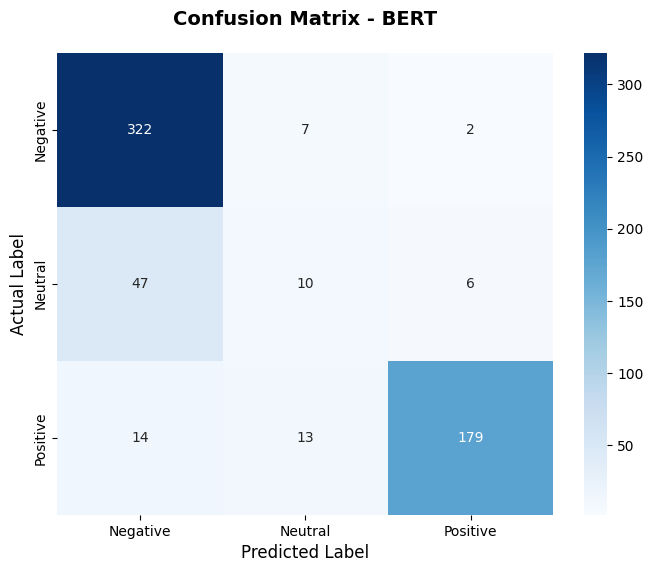


PERFORMANCE EVALUATION: RoBERTa


Accuracy  : 0.8633
F1-Macro  : 0.7154
AUC Score : 0.9190

--- Detailed Classification Report ---
              precision    recall  f1-score   support

    Negative       0.87      0.95      0.91       331
     Neutral       0.42      0.25      0.32        63
    Positive       0.93      0.91      0.92       206

    accuracy                           0.86       600
   macro avg       0.74      0.71      0.72       600
weighted avg       0.84      0.86      0.85       600



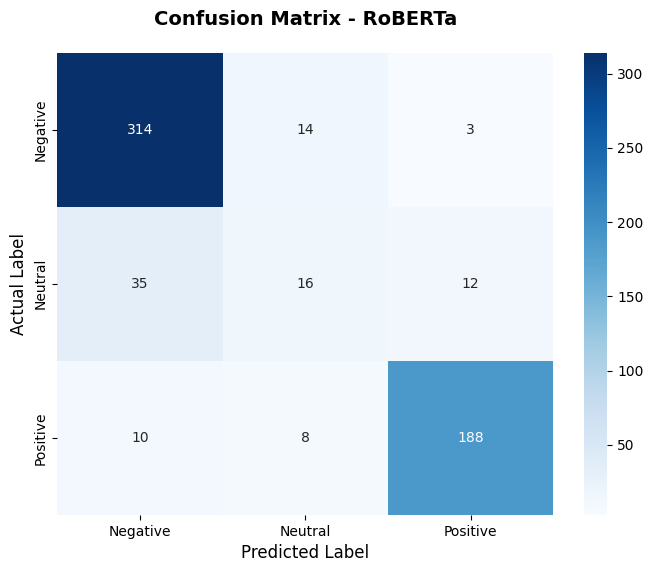


PERFORMANCE EVALUATION: DeBERTa


Accuracy  : 0.8650
F1-Macro  : 0.7203
AUC Score : 0.9167

--- Detailed Classification Report ---
              precision    recall  f1-score   support

    Negative       0.88      0.95      0.91       331
     Neutral       0.39      0.27      0.32        63
    Positive       0.95      0.92      0.93       206

    accuracy                           0.86       600
   macro avg       0.74      0.71      0.72       600
weighted avg       0.85      0.86      0.86       600



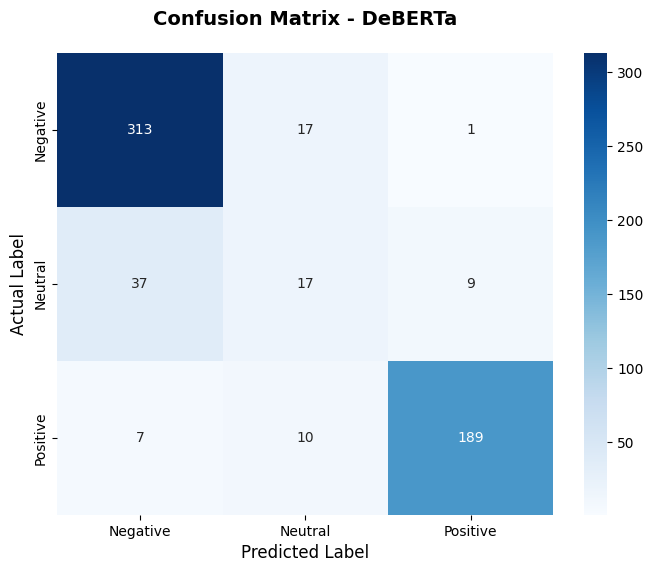

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    f1_score,
    roc_auc_score
)
from scipy.special import softmax

def evaluate_model_full(model_name, df_results, trainer_obj, tokenizer_obj):
    print(f"\n{'='*60}\nPERFORMANCE EVALUATION: {model_name}\n{'='*60}")

    # 1. Prepare Testing Dataset for Evaluation
    eval_ds = AirlineReviewDataset(
        df_results['Result_Normalization'],
        df_results['label'],
        tokenizer_obj
    )

    # 2. Extract Ground Truth and Predictions
    y_true = df_results['label'].values

    # Mapping sentiment labels to numeric indices
    mapping = {'negative': 0, 'neutral': 1, 'positive': 2}
    y_pred = df_results[f'Sentiment_{model_name}'].map(mapping).values

    # 3. Extract Logits for AUC Calculation (Probabilities)
    output = trainer_obj.predict(eval_ds)
    probs = softmax(output.predictions, axis=1)

    # 4. Calculate Primary Metrics
    acc = accuracy_score(y_true, y_pred)
    f1_macro = f1_score(y_true, y_pred, average='macro')
    auc_score = roc_auc_score(y_true, probs, multi_class='ovr')

    print(f"Accuracy  : {acc:.4f}")
    print(f"F1-Macro  : {f1_macro:.4f}")
    print(f"AUC Score : {auc_score:.4f}")
    print("\n--- Detailed Classification Report ---")
    print(classification_report(
        y_true,
        y_pred,
        target_names=['Negative', 'Neutral', 'Positive']
    ))

    # 5. Visualization: Confusion Matrix Heatmap
    plt.figure(figsize=(8, 6))
    cm = confusion_matrix(y_true, y_pred)
    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap='Blues',
        xticklabels=['Negative', 'Neutral', 'Positive'],
        yticklabels=['Negative', 'Neutral', 'Positive']
    )

    plt.title(f'Confusion Matrix - {model_name}', fontsize=14, fontweight='bold', pad=20)
    plt.xlabel('Predicted Label', fontsize=12)
    plt.ylabel('Actual Label', fontsize=12)
    plt.show()

# --- EXECUTE EVALUATION FOR ALL MIDDLE EASTERN MODELS ---
evaluate_model_full("BERT", df_res_bert, trainer_bert, tokenizer_bert)
evaluate_model_full("RoBERTa", df_res_rob, trainer_rob, tokenizer_rob)
evaluate_model_full("DeBERTa", df_res_deb, trainer_deb, tokenizer_deb)

# **MULTI-CLASS ROC-AUC VISUALIZATION**

Generating ROC Curve for BERT...


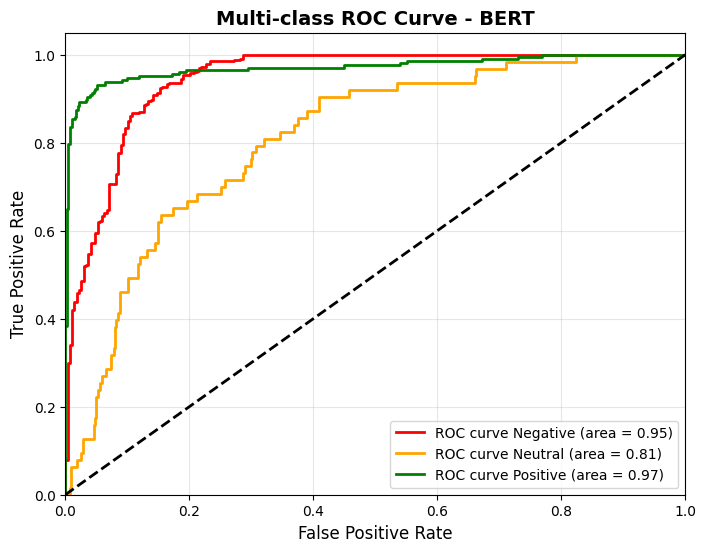

Generating ROC Curve for RoBERTa...


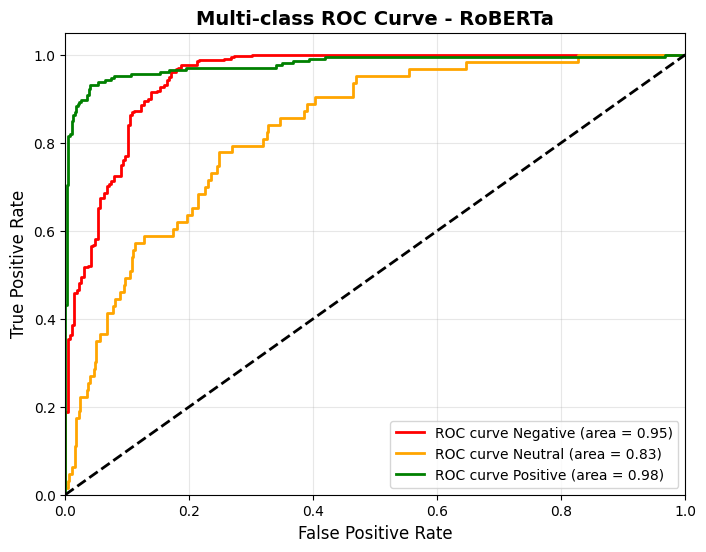

Generating ROC Curve for DeBERTa...


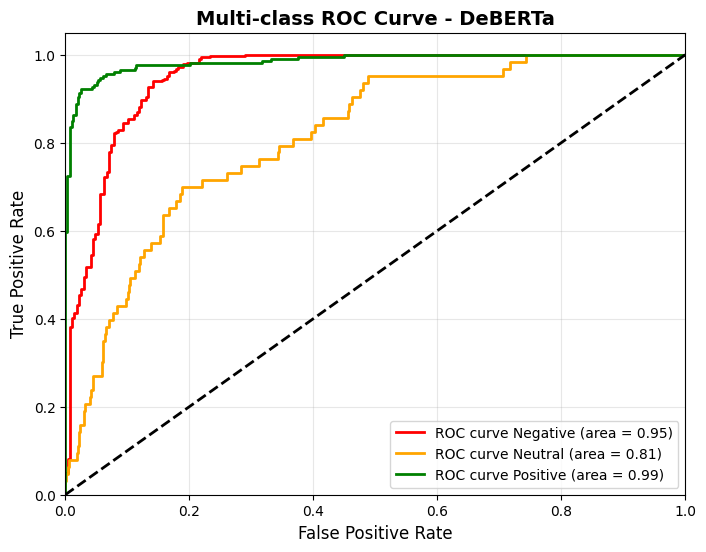

In [ ]:
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize

def plot_multiclass_roc(model_name, df_results, trainer_obj, tokenizer_obj):
    print(f"Generating ROC Curve for {model_name}...")

    # 1. Data Preparation & Probability Extraction
    eval_ds = AirlineReviewDataset(
        df_results['Result_Normalization'],
        df_results['label'],
        tokenizer_obj
    )
    y_true = df_results['label'].values
    output = trainer_obj.predict(eval_ds)
    y_score = softmax(output.predictions, axis=1)

    # 2. Binarize labels for multi-class (0: Negative, 1: Neutral, 2: Positive)
    n_classes = 3
    y_true_bin = label_binarize(y_true, classes=[0, 1, 2])

    # 3. Compute ROC curve and ROC area for each class
    fpr = dict()
    tpr = dict()
    roc_auc = dict()
    class_names = ['Negative', 'Neutral', 'Positive']
    colors = ['red', 'orange', 'green']

    plt.figure(figsize=(8, 6))

    for i in range(n_classes):
        fpr[i], tpr[i], _ = roc_curve(y_true_bin[:, i], y_score[:, i])
        roc_auc[i] = auc(fpr[i], tpr[i])

        plt.plot(
            fpr[i], tpr[i],
            color=colors[i],
            lw=2,
            label=f'ROC curve {class_names[i]} (area = {roc_auc[i]:.2f})'
        )

    # 4. Plot Diagonal Line (Random Guess Baseline)
    plt.plot([0, 1], [0, 1], 'k--', lw=2)

    # 5. Graph Aesthetics
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate', fontsize=12)
    plt.ylabel('True Positive Rate', fontsize=12)
    plt.title(f'Multi-class ROC Curve - {model_name}', fontsize=14, fontweight='bold')
    plt.legend(loc="lower right")
    plt.grid(alpha=0.3)
    plt.show()

# --- EXECUTE AUC VISUALIZATION FOR ALL 3 MIDDLE EASTERN MODELS ---
plot_multiclass_roc("BERT", df_res_bert, trainer_bert, tokenizer_bert)
plot_multiclass_roc("RoBERTa", df_res_rob, trainer_rob, tokenizer_rob)
plot_multiclass_roc("DeBERTa", df_res_deb, trainer_deb, tokenizer_deb)

# **E. XAI MODULE (EXPLAINABLE AI)**

In [ ]:
from IPython.display import display, HTML
import re
import numpy as np
import torch
import scipy as sp
import pandas as pd
import shap

# 1. Pastikan device didefinisikan (menggunakan GPU jika tersedia)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [ ]:
# --- PART 1: SAMPLE SELECTION (Target: 20-40 words) ---
# Memilih sampel ulasan dari dataset Middle Eastern untuk dianalisis
df_temp = df_test.copy()
# Memastikan kolom teks yang digunakan adalah hasil normalisasi
col_to_check = 'Result_Normalization'
df_temp['num_words'] = df_temp[col_to_check].apply(lambda x: len(str(x).split()))

def get_medium_sample(df, label_value, min_w=20, max_w=40):
    filtered_df = df[(df['label'] == label_value) &
                     (df['num_words'] >= min_w) &
                     (df['num_words'] <= max_w)]
    if filtered_df.empty:
        # Fallback jika tidak ada sampel dalam rentang kata yang diinginkan
        filtered_df = df[(df['label'] == label_value) & (df['num_words'] > 15)]
    return filtered_df[col_to_check].iloc[0] if not filtered_df.empty else "Data not found"

# Mengambil satu sampel untuk setiap kategori sentimen
text_neg_me = get_medium_sample(df_temp, 0) # Negative
text_net_me = get_medium_sample(df_temp, 1) # Neutral
text_pos_me = get_medium_sample(df_temp, 2) # Positive

xai_samples_me = np.array([text_neg_me, text_net_me, text_pos_me])

# --- PREVIEW: DATA SAMPLES FOR XAI ANALYSIS ---
print(f"{'='*75}")
print(f"PREVIEW: DATA SAMPLES FOR XAI ANALYSIS (MIDDLE EASTERN AIRLINES)")
print(f"{'='*75}")

preview_data_me = pd.DataFrame({
    'Sentiment': ['NEGATIVE', 'NEUTRAL', 'POSITIVE'],
    'Sample Review': [text_neg_me, text_net_me, text_pos_me],
    'Word Count': [len(text_neg_me.split()), len(text_net_me.split()), len(text_pos_me.split())]
})

display(HTML(preview_data_me.to_html(index=False)))
print("\n")

PREVIEW: DATA SAMPLES FOR XAI ANALYSIS (MIDDLE EASTERN AIRLINES)


Sentiment,Sample Review,Word Count
NEGATIVE,worst service flight time is pm midday but no a c either in passenger bus or in flight all passengers are sitting in hot conditions worse than budget airlines,29
NEUTRAL,denpasar to riyadh via dubai beware of the business class special as it restricts seat selection it also doesn t permit the lounge access,24
POSITIVE,wonderful service while flying on emirates clean planes good food and wonderful crew my flight from dubai to london on the a was a wonderful experience i would highly recommend this flight,32


In [ ]:
# --- PART 2: SHAP HTML FIX ---
# Fungsi untuk memperbaiki rendering warna pada visualisasi SHAP di notebook
def fix_shap_html(html):
    def replace_rgb(match):
        nums = re.findall(r'np\.float64\(([\d.e+-]+)\)', match.group(0))
        if len(nums) == 3:
            r, g, b = [float(n) for n in nums]
            return f'rgb({r:.0f}, {g:.0f}, {b:.0f})'
        return match.group(0)

    def replace_rgba(match):
        nums = re.findall(r'np\.float64\(([\d.e+-]+)\)', match.group(0))
        if len(nums) == 4:
            r, g, b, a = [float(n) for n in nums]
            return f'rgba({r:.0f}, {g:.0f}, {b:.0f}, {a:.4f})'
        return match.group(0)

    html = re.sub(
        r'rgba\(np\.float64\([^)]+\),\s*np\.float64\([^)]+\),\s*np\.float64\([^)]+\),\s*np\.float64\([^)]+\)\)',
        replace_rgba, html
    )
    html = re.sub(
        r'rgb\(np\.float64\([^)]+\),\s*np\.float64\([^)]+\),\s*np\.float64\([^)]+\)\)',
        replace_rgb, html
    )
    return html

# --- PART 3: SHAP VISUALIZATION FUNCTION ---
def run_xai_shap_me(model_obj, tokenizer_obj, model_name, samples):
    print(f"\n{'='*75}\nEXPLAINABLE AI (SHAP) - MIDDLE EASTERN ANALYSIS: {model_name}\n{'='*75}")

    def predict_probs(texts):
        inputs = tokenizer_obj(texts.tolist(), return_tensors="pt", padding=True,
                               truncation=True, max_length=128).to(device)
        with torch.no_grad():
            logits = model_obj(**inputs).logits
        return sp.special.softmax(logits.cpu().numpy(), axis=1)

    # Inisialisasi explainer menggunakan masker teks
    explainer = shap.Explainer(predict_probs, tokenizer_obj)
    shap_values = explainer(samples)

    label_names = {0: "NEGATIVE", 1: "NEUTRAL", 2: "POSITIVE"}

    # Melakukan visualisasi untuk setiap sampel sesuai kelas targetnya
    for i, (sample_idx, class_idx) in enumerate([(0, 0), (1, 1), (2, 2)]):
        label = label_names[class_idx]
        print(f"\n>> [SAMPLE {i+1}] Token Contribution Analysis for {label} Prediction:")

        # Generate plot dalam format HTML
        html_output = shap.plots.text(shap_values[sample_idx, :, class_idx], display=False)
        fixed_html = fix_shap_html(html_output)

        display(HTML(f"""
        <div style="background:white; padding:15px; border-radius:8px;
                    border:1px solid #e0e0e0; margin:8px 0; overflow-x: auto;">
            {fixed_html}
        </div>
        """))

# --- EXECUTION: RUNNING XAI FOR ALL MODELS ---
# Pastikan model model_bert, model_rob, dan model_deb sudah dilatih sebelumnya
run_xai_shap_me(model_bert, tokenizer_bert, "BERT", xai_samples_me)
run_xai_shap_me(model_rob, tokenizer_rob, "RoBERTa", xai_samples_me)
run_xai_shap_me(model_deb, tokenizer_deb, "DeBERTa", xai_samples_me)


EXPLAINABLE AI (SHAP) - MIDDLE EASTERN ANALYSIS: BERT


PartitionExplainer explainer: 4it [00:11, 11.29s/it]               


>> [SAMPLE 1] Token Contribution Analysis for NEGATIVE Prediction:



>> [SAMPLE 2] Token Contribution Analysis for NEUTRAL Prediction:



>> [SAMPLE 3] Token Contribution Analysis for POSITIVE Prediction:


...

  0%|          | 0/498 [00:00<?, ?it/s]

PartitionExplainer explainer: 4it [00:14,  7.36s/it]


>> [SAMPLE 1] Token Contribution Analysis for NEGATIVE Prediction:



>> [SAMPLE 2] Token Contribution Analysis for NEUTRAL Prediction:



>> [SAMPLE 3] Token Contribution Analysis for POSITIVE Prediction:
